<a href="https://colab.research.google.com/github/eduardofmj97/EBAC/blob/main/Profissao_Cientista_de_Dados_M17_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [ ]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1(1).csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [ ]:
df.dtypes

,0
Age,float64
Gender,object
Income,object
Education,object
Marital Status,object
Number of Children,int64
Home Ownership,object
Credit Score,object


Como nosso principal foco de análise, precisamos que o Income seja numérico ao invés de objeto. Por isso, o trataremos para torná-lo float

In [ ]:
df['Income'] = df['Income'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

In [ ]:
df['Income'].dtypes

dtype('float64')

**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    float64
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 10.4+ KB


In [ ]:
df.isnull().values.any()

np.True_

In [ ]:
df.isnull().sum()

,0
Age,34
Gender,0
Income,0
Education,0
Marital Status,0
Number of Children,0
Home Ownership,0
Credit Score,0


In [ ]:
print(f"Mediana: {df['Age'].median()}")

print(f"Média: {df['Age'].mean()}")

Mediana: 36.0
Média: 37.50769230769231


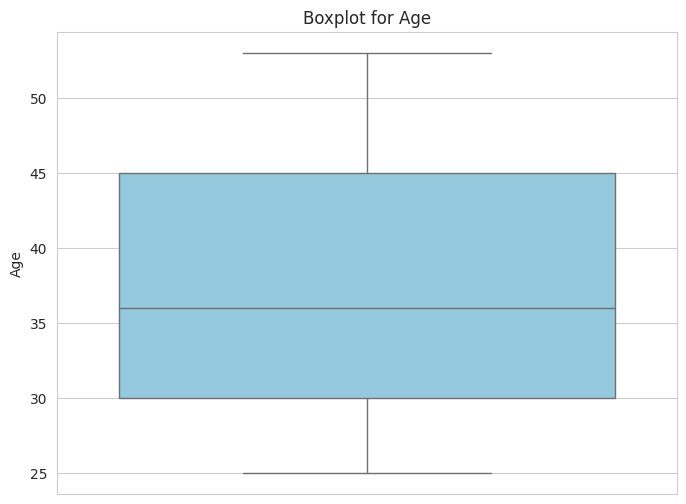

In [ ]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Age', color='skyblue')
plt.title('Boxplot for Age')
plt.ylabel('Age')
plt.show()

Somente a coluna Age possui dados faltantes, totalizando 34 entradas. Não possuímos nenhum outlier, de acordo com a representação gráfica e os valores de média e mediana são relativamente próximos. Sendo assim, iremos tratá-la adequedamente a seguir através da substituição dos valores nulos pela mediana das idades visto que o dataset já é pequeno e devemos evitar o enviesamento da análise, além da mediana representar um valor sem casas decimais.

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'].describe()

,Age
count,164.000000
mean,37.195122
std,7.586619
min,25.000000
25%,31.750000
50%,36.000000
75%,43.000000
max,53.000000


**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [ ]:
print('Valores únicos por coluna:')
print(f'Gender: {df['Gender'].unique()}')
print(f' Education: {df['Education'].unique()}')
print(f' Marital Status: {df['Marital Status'].unique()}')
print(f' Home Ownership: {df['Home Ownership'].unique()}')
print(f' Credit Score: {df['Credit Score'].unique()}')

Valores únicos por coluna:
Gender: ['Female' 'Male']
 Education: ["Bachelor's Degree" "Master's Degree" 'Doctorate' 'High School Diploma'
 "Associate's Degree"]
 Marital Status: ['Single' 'Married']
 Home Ownership: ['Rented' 'Owned']
 Credit Score: ['High' 'Average' 'Low']


Ao analisarmos, podemos concluir que não há valores digitados de forma incorreta nas variáveis, logo, não há necessidade desse tipo de tratamento.

# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [ ]:
df.describe()

,Age,Income,Number of Children
count,164.000000,164.000000,164.000000
mean,37.195122,83765.243902,0.652439
std,7.586619,32457.306728,0.883346
min,25.000000,25000.000000,0.000000
25%,31.750000,57500.000000,0.000000
50%,36.000000,83750.000000,0.000000
75%,43.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


Ao analisarmos os valores numéricos, podemos notar que há uma grande variedade em Income, sendo nosso principal objeto de estudo. Devemos melhorar a forma de visualização para detectarmos possíveis outliers através de um boxplot e um histograma.

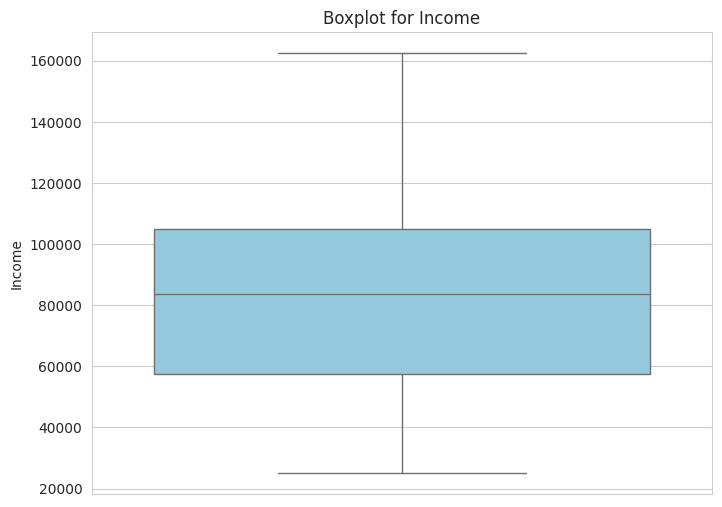

In [ ]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Income', color='skyblue')
plt.title('Boxplot for Income')
plt.ylabel('Income')
plt.show()

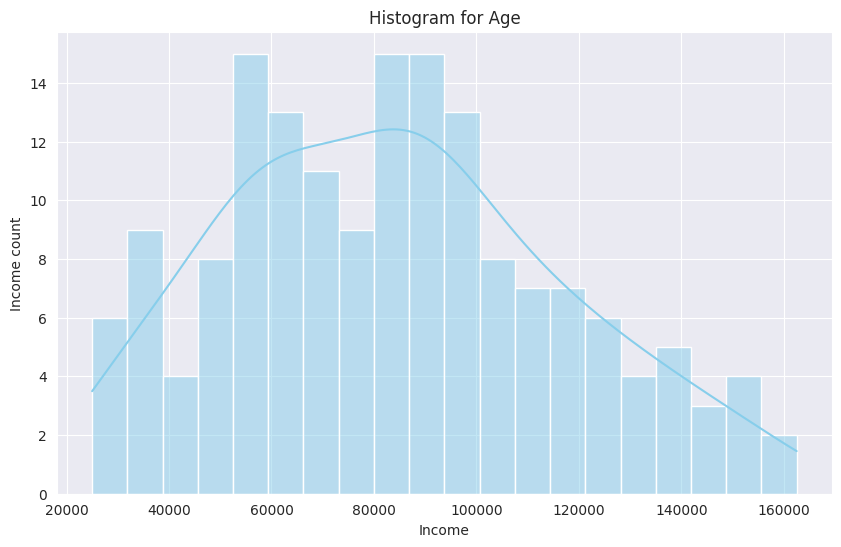

In [ ]:
sns.set_style('darkgrid')
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Income', bins=20, kde=True, color='skyblue')
plt.title('Histogram for Age')
plt.xlabel('Income')
plt.ylabel('Income count')
plt.show()

De acordo com a visualização, podemos notar que os dados estão bem distribuídos uma vez que a contagem de valores nos máximos e mínimos é similar e equilibrada. Além disso, é importante considerarmos que nossa base é pequena, com somente 164 entradas. Remover ou substituir os valores máximos e mínimos pode tornar nossa análise enviesada, então não faremos esse tipo de tratamento.

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

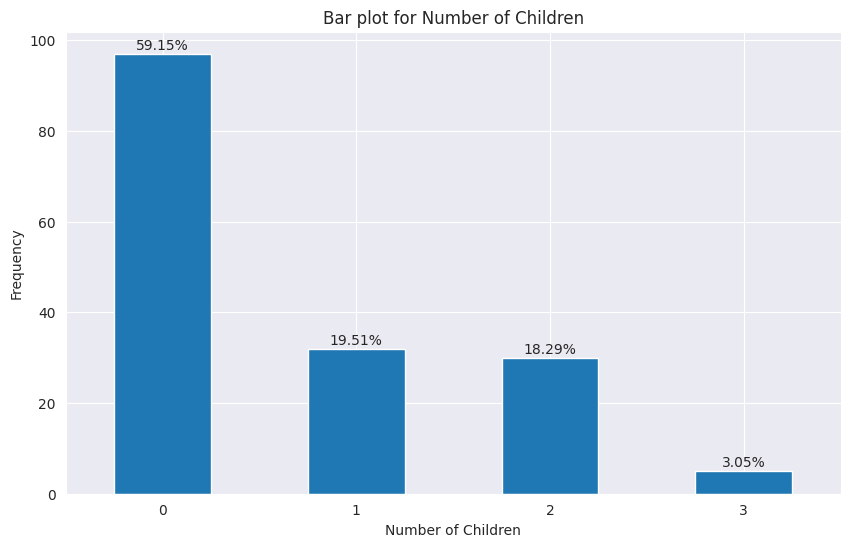

In [ ]:
child_count = df['Number of Children'].value_counts()
child_percentage = (child_count / child_count.sum())*100

ax = child_count.plot(kind='bar', figsize=(10,6))

for i, v in enumerate(child_count):
  ax.text(i, v + 1 ,f'{child_percentage[i]:.2f}%', ha='center')
plt.title('Bar plot for Number of Children')
plt.xlabel('Number of Children')
plt.xticks(rotation=0)
plt.ylabel('Frequency')

plt.show()

Pela distribuição da variável Number of Child, podemos notar que no database aproximadamente 59% dos indivíduos não tem filhos. Esse possivelmente é um ponto importante para ser melhor analisado e correlacionado em breve nesse estudo. No momento, vamos prosseguir com as demais análises univariadas

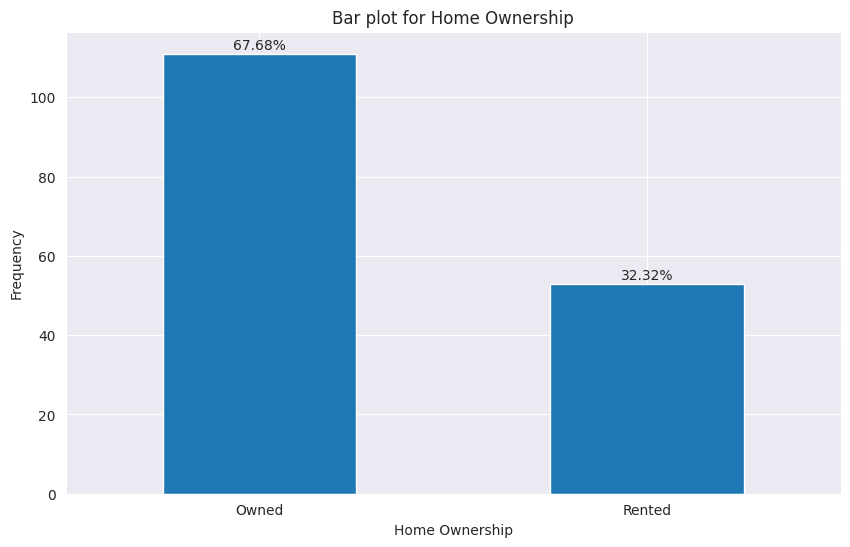

In [ ]:
home_count = df['Home Ownership'].value_counts()
home_percentage = (home_count / home_count.sum())*100

ax = home_count.plot(kind='bar', figsize=(10,6))

for i, v in enumerate(home_count):
  ax.text(i, v + 1 ,f'{home_percentage.iloc[i]:.2f}%', ha='center')
plt.title('Bar plot for Home Ownership')
plt.xlabel('Home Ownership')
plt.xticks(rotation=0)
plt.ylabel('Frequency')

plt.show()

Agora, analisando o percentual de pessoas que possuem casa própria ou vivem de aluguel, podemos notar que 67%, ou seja, 2/3 das pessoas possuem casa própria. Possivelmente é um fator importante que irá influenciar futuramente em nossa análise de crédito.

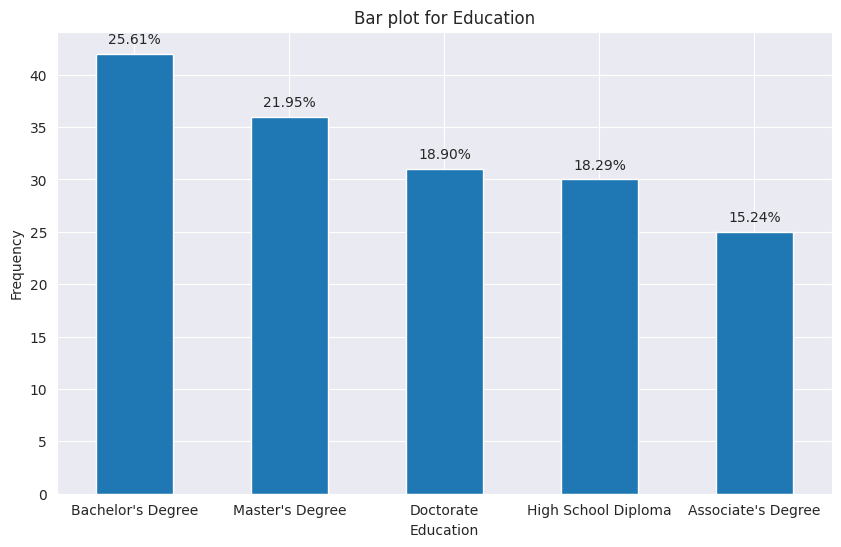

In [ ]:
education_count = df['Education'].value_counts()
education_percentage = (education_count / education_count.sum())*100

ax = education_count.plot(kind='bar', figsize=(10,6))

for i, v in enumerate(education_count):
  ax.text(i, v + 1 ,f'{education_percentage.iloc[i]:.2f}%', ha='center')
plt.title('Bar plot for Education')
plt.xlabel('Education')
plt.xticks(rotation=0)
plt.ylabel('Frequency')

plt.show()

O nível de educação entre os integrantes do banco de dados se dispõe de forma bem equilibrada. Não há uma discrepância muito grande entre os dados dessa variável. Em breve veremos se há relação direta ou não com a análise de crédito.

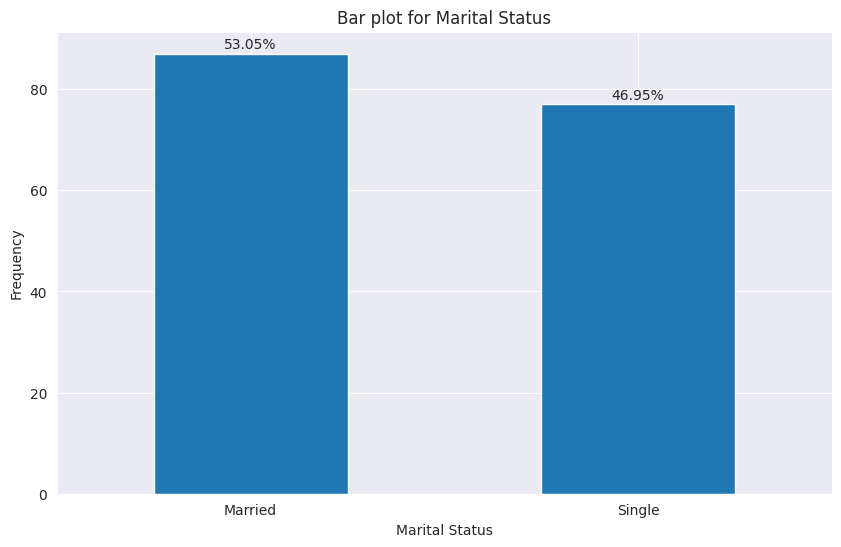

In [ ]:
marriage_count = df['Marital Status'].value_counts()
marriage_percentage = (marriage_count / marriage_count.sum())*100

ax = marriage_count.plot(kind='bar', figsize=(10,6))

for i, v in enumerate(marriage_count):
  ax.text(i, v + 1 ,f'{marriage_percentage.iloc[i]:.2f}%', ha='center')
plt.title('Bar plot for Marital Status')
plt.xlabel('Marital Status')
plt.xticks(rotation=0)
plt.ylabel('Frequency')

plt.show()

Há também um equilíbrio entre o estado conjugal dos indivíduos, sendo quase iguais as quantidades de casados e solteiros em nossos dados.

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

O único dado que possivelmente pode representar outliers são de pessoas com 3 filhos, que representam 3,05% dos indivíduos do estudo. Porém, é possível que esse dado seja crucial para determinação do Credit Score. Sendo assim, irei manter os dados sem realizar o tratamento no momento e realizar as análises biveriadas para tentar detectar alguma correlação.

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



In [ ]:
fig1 = px.histogram(df, x='Age', color='Marital Status', barmode='stack', text_auto=True)

fig1.update_layout(title='Correlation between Age and Marital Status',
                  xaxis_title='Age',
                  yaxis_title='Count',
                  legend_title='Marital Status')

fig1.show()

Podemos notar uma relação entre idade e estado civil uma vez que a maior parte das pessoas solteiras se concentra entre 25 e 34 anos, aumentando gradativamente até os 34, onde ocorre um inversão de dados, apresentando um salto significativo no número de pessoas casadas.
Porém, há uma lacuna entre 40 e 43 anos de idade onde todos os clientes são solteiros. Possivelmente representa clientes divorciados.
Após os 45 anos, notamos novamente a prevalência de clientes casados, sem nenhum solteiro após os 46 anos.

In [ ]:
# Corrigindo a ordem em que os rótulos devem aparecer no gráfico
education_order = [
    'High School Diploma',
    "Associate's Degree",
    "Bachelor's Degree",
    "Master's Degree",
    'Doctorate'
]

fig2 = px.histogram(df, x='Education', color='Credit Score', barmode='stack', text_auto=True,
                  category_orders={'Education': education_order})

fig2.update_layout(title='Correlation between Credit Score and Education',
                  xaxis_title='Education',
                  yaxis_title='Count',
                  legend_title='Credit Score')

fig2.show()

Podemos notar uma correlação direta entre o nível de escolaridade e o Credit Score onde quanto maior a escolaridade, maior o score. Os créditos baixos se concentram em níveis menores de educação enquanto que os níveis maiores recebem uma melhor avaliação.

In [ ]:
fig3 = px.scatter(df, x='Income', y='Age', color="Income",
                  size='Income', hover_data=['Age'])

fig3.update_layout(title='Correlation between Income and Age',
                  xaxis_title='Income',
                  yaxis_title='Count',
                  legend_title='Age')

fig3.show()

De acordo com o gráfico de dispersão, notamos claramente que a renda anual está diretamente relacionada com a idade dos clientes, uma vez que os maiores salários se concentram em indivíduos de maior idade e os menores salários, em indivíduos de menor idade.

In [ ]:
fig4 = px.histogram(df, x='Income', color='Credit Score', barmode='stack', text_auto=True)

fig4.update_layout(title='Correlation between Income and Credit Score',
                  xaxis_title='Income',
                  yaxis_title='Count',
                  legend_title='Credit Score')

fig4.show()

Podemos notar que também há uma relação direta entre o Credit Score e a renda anual baseado nessa visualização onde o escore de crédito se torna gradativamente melhor de forma diretamente proporcional à renda.

In [ ]:
fig5 = px.histogram(df, x='Home Ownership', color='Credit Score', barmode='stack', text_auto=True)

fig5.update_layout(title='Correlation between Home Ownership and Credit Score',
                  xaxis_title='Home Ownership',
                  yaxis_title='Count',
                  legend_title='Credit Score')

fig5.show()

Há também a definição clara de que os indivíduos que possuem casa própria tem as melhores avaliações de Credit Score. Notamos também que as menores avaliações estão completamente concentradas naqueles indivíduos que moram de aluguel.

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

O estado civil pode influenciar no Credit Score?

In [ ]:
fig6 = px.histogram(df, x='Marital Status', color='Credit Score', barmode='stack', text_auto=True)

fig6.update_layout(title='Correlation between Credit Score and Marital Status',
                  xaxis_title='Marital Status',
                  yaxis_title='Values',
                  legend_title='Credit Score')

fig6.show()

Também há correlação direta com o estado civil e a análise de crédito

A idade pode influenciar no Credit Score?

In [ ]:
fig7 = px.histogram(df, x='Age', color='Credit Score', barmode='stack', text_auto=True)

fig7.update_layout(title='Correlation between Credit Score and Age',
                  xaxis_title='Age',
                  yaxis_title='Values',
                  legend_title='Credit Score')

fig7.show()

Também podemos notar que quanto maior a idade, a avaliação de crédito também tende a ser melhor

O número de filhos pode influenciar no Credit Score?

In [ ]:
fig8 = px.histogram(df, x='Number of Children', color='Credit Score', barmode='stack', text_auto=True)

fig8.update_layout(title='Correlation between Credit Score and Number of Children',
                  xaxis_title='Number of Children',
                  yaxis_title='Values',
                  legend_title='Credit Score')

# Ensure x-axis ticks are integers
fig8.update_xaxes(dtick=1)

fig8.show()

Por último, também podemos notar que o Credit Score está correlacionado ao número de filhos uma vez que quanto mais filhos, melhor o Score. Essa afirmação se torna um pouco peculiar pois não podemos afirmar que ter mais filhos garante melhor score, mas sim que indivíduos que tem mais filhos geralmente tem uma melhor condição financeira, imóvel próprio e tendem a ser casados, ou seja, fatoras cruciais para o aumento do Score. Podemos então afirmar que a correlação não implica em causalidade.

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

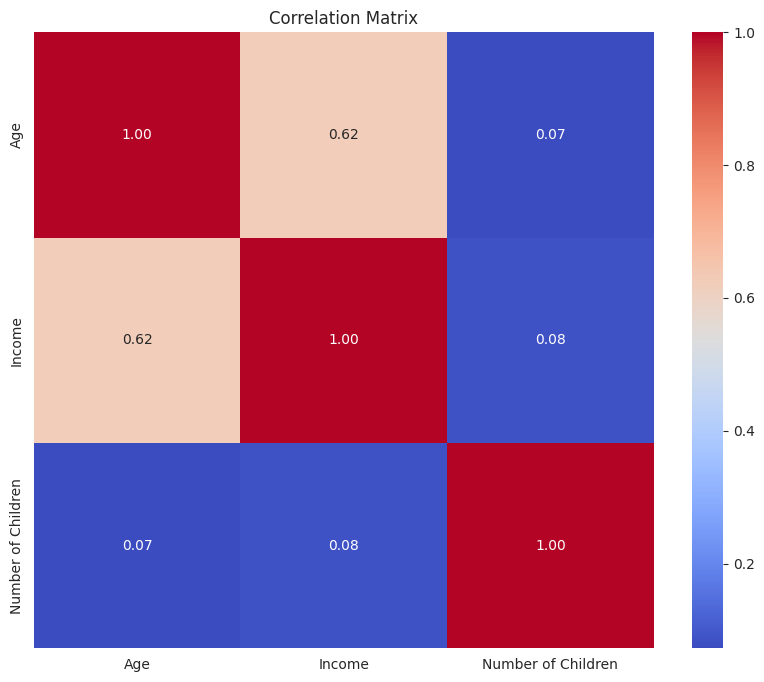

In [ ]:
corr_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Correlation Matrix')
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

Com a visualização atual, podemos notar que existe uma certa correlação, por mais que não seja muito forte, entre a idade e a renda anual.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

No caso das categorias Education e Credit Score, após algumas tentativas, concluí que será melhor fazer uso de dicionários para definição manual das categorias uma vez que a função Label Encoder iria utilizar a ordem alfabética para realizar a classificação, o que não é ideal para variáveis onde os valores possuem peso intrínseco entre si. Já nas categorias Marital Status, Home Owership e Gender podemos utilizar o One hot Encoder para realizarmos as classificações visto que são categorias binárias sem ordem de grandeza entre seus valores.

In [ ]:
education_mapping = {"High School Diploma": 0, "Associate's Degree": 1, "Bachelor's Degree": 2, "Master's Degree": 3, "Doctorate": 4}
df['Education'] = df['Education'].map(education_mapping)

credit_score_mapping = {'Low': 0, 'Average': 1, 'High': 2}
df['Credit Score'] = df['Credit Score'].map(credit_score_mapping)

df = pd.get_dummies(df, columns=['Marital Status', 'Home Ownership', 'Gender'], drop_first=True)

print(df)

      Age    Income  Education  Number of Children  Credit Score  \
0    25.0   50000.0          2                   0             2   
1    30.0  100000.0          3                   2             2   
2    35.0   75000.0          4                   1             2   
3    40.0  125000.0          0                   0             2   
4    45.0  100000.0          2                   3             2   
..    ...       ...        ...                 ...           ...   
159  29.0   27500.0          0                   0             0   
160  34.0   47500.0          1                   0             1   
161  39.0   62500.0          2                   2             2   
162  44.0   87500.0          3                   0             2   
163  49.0   77500.0          4                   1             2   

     Marital Status_Single  Home Ownership_Rented  Gender_Male  
0                     True                   True        False  
1                    False                  False    

Agora iremos transformar as colunas de booleanos para inteiros:

In [ ]:
for column in df.columns:
  if df[column].dtype == 'bool':
    df[column] = df[column].astype(int)
print(df)

      Age    Income  Education  Number of Children  Credit Score  \
0    25.0   50000.0          2                   0             2   
1    30.0  100000.0          3                   2             2   
2    35.0   75000.0          4                   1             2   
3    40.0  125000.0          0                   0             2   
4    45.0  100000.0          2                   3             2   
..    ...       ...        ...                 ...           ...   
159  29.0   27500.0          0                   0             0   
160  34.0   47500.0          1                   0             1   
161  39.0   62500.0          2                   2             2   
162  44.0   87500.0          3                   0             2   
163  49.0   77500.0          4                   1             2   

     Marital Status_Single  Home Ownership_Rented  Gender_Male  
0                        1                      1            0  
1                        0                      0    

**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

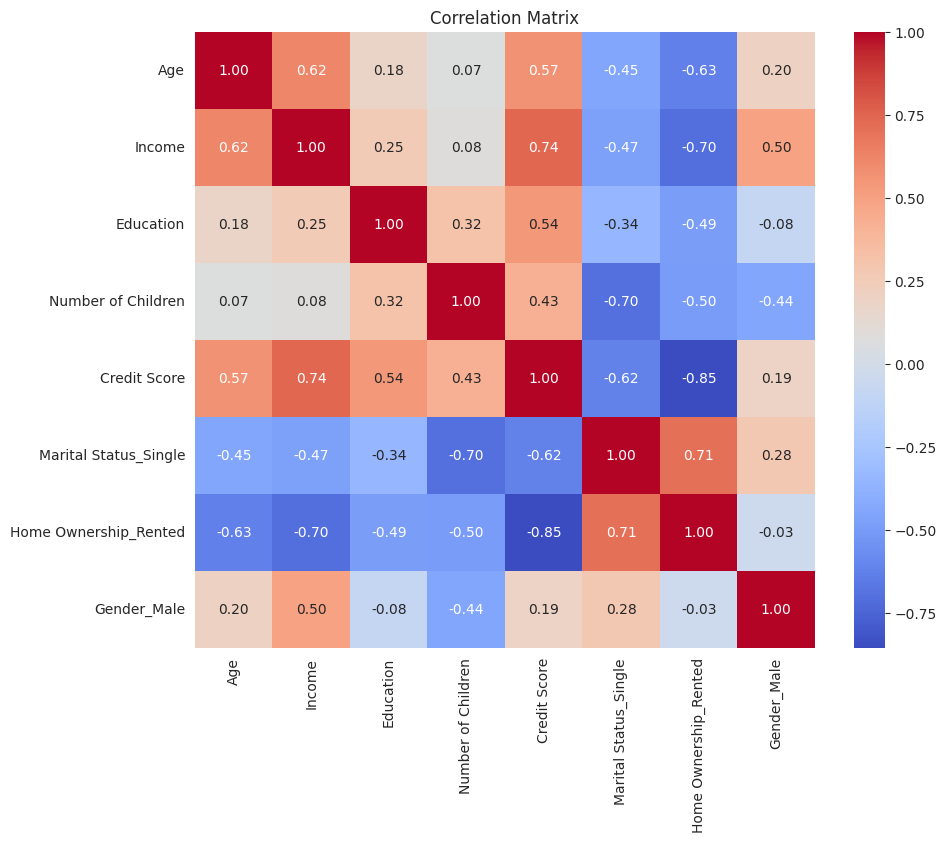

In [ ]:
corr_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Correlation Matrix')
plt.show()

Com essa nova análise, podemos ver que há fortíssimas relações entre Credit Score e Aluguel e Credit Score e renda anual. Nesse caso, viver de aluguel tem uma correlação negativa com o score de crédito enquanto que o salário anual tem uma correlação positiva, ambas com valores de -0.85 e 0.74 respectivamente

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [ ]:
X = df.drop('Credit Score', axis=1)
y = df['Credit Score']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
print("Tamanho de  X_train:", X_train.shape)
print("Tamanho de  y_train:", y_train.shape)
print("Tamanho de  X_test:", X_test.shape)
print("Tamanho de  y_test:", y_test.shape)

Tamanho de  X_train: (123, 7)
Tamanho de  y_train: (123,)
Tamanho de  X_test: (41, 7)
Tamanho de  y_test: (41,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

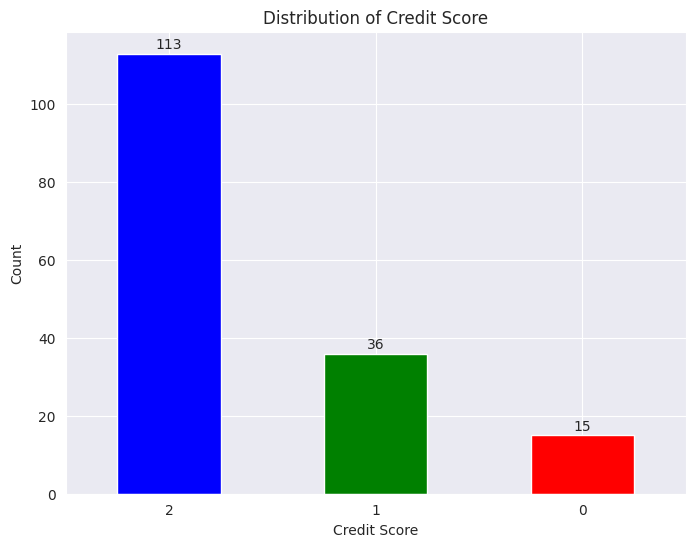

In [ ]:
credit_score_counts = df['Credit Score'].value_counts()
plt.figure(figsize=(8,6))
ax = credit_score_counts.plot(kind='bar', color=['blue', 'green', 'red'])

 # Adicionando rótulo dos dados das barras
for i, v in enumerate(credit_score_counts):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [ ]:
print((df['Credit Score'].value_counts(normalize=True) * 100))

Credit Score
2    68.902439
1    21.951220
0     9.146341
Name: proportion, dtype: float64


De acordo com o gráfico e a análise percentual, podemos ver que claramente o Credit Score não está bem balanceado, demonstrando somente 15 entradas com score low enquanto há 113 entradas com score high

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Distribuição após o balanceamento:")
print(y_train_balanced.value_counts())

Distribuição após o balanceamento:
Credit Score
1    84
0    84
2    84
Name: count, dtype: int64


In [ ]:
y_train_balanced.to_csv('y_train_balanced.csv', index=False)

In [ ]:
X_train_balanced.to_csv('X_train_balanced.csv', index=False)

In [ ]:
y_test.to_csv('y_test.csv', index=False)

In [ ]:
X_test.to_csv('X_test.csv', index=False)